## Analisi della densità polifonica ##
Questo notebook consente di analizzare la densità polifonica di una composizione<br>
restituendo grafici che indicano l'attività di ciascuna voce e il numero complessivo<br>
delle voci attive lungo la composizione

### Importazione ###
È necessario eseguire la prossima cella per caricare il codice che analizza<br>
le composizioni e genera i grafici.

In [ ]:
# ── Colab setup (run once) ────────────────────────────────────────────────────
!pip install -q crim-intervals

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Analisi_tecniche_forme_2025_2026')

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, HTML
import base64
from crim_intervals import importScore
import plotly.graph_objects as go

def download_html(fig, filename='chart.html'):
    b64 = base64.b64encode(fig.to_html(include_plotlyjs='cdn').encode()).decode()
    display(HTML(
        f'<a href="data:text/html;base64,{b64}" download="{filename}" '
        f'style="display:inline-block;margin-top:6px;padding:4px 14px;background:#4472C4;'
        f'color:#fff;border-radius:4px;text-decoration:none;font-size:12px;">⬇ {filename}</a>'
    ))

print('Ok')

Ok


#### Caricamento della composizione ###

In [20]:
path = 'Music_Files/'
filename = 'Marenzio_o_voi.xml' # ← cambia questo valore per caricare un altro file (usa le virgolette '')
url = path+filename   
piece     = importScore(url)
print(piece.metadata)

{'title': 'O voi che sospirate', 'composer': 'Luca Marenzio', 'date': None}


In [21]:
n         = piece.notes()
d         = piece.durations()
sound     = piece.soundingCount()
n_d_sound = pd.concat([n, d, sound], axis=1)

output = piece.detailIndex(df=n_d_sound, progress=True).reset_index()
output["Composer"] = piece.metadata['composer']
output["Title"]    = piece.metadata['title']
output["path"]     = Path(url).name

first_cols = ["Measure", "Beat", "Composer", "Title", "path"]
output = output[first_cols + [c for c in output.columns if c not in first_cols]]

print(f"Loaded: {piece.metadata['title']}  —  {piece.metadata['composer']}")

Loaded: O voi che sospirate  —  Luca Marenzio


## Analisi della densità polifonica ##

### Attività delle voci ###
L'asse y di questo grafico è popolata di tante righe quante sono le voci della composizione.<br>
L'asse x rappresenta il 'progresso' (progress) della composizione ossia il suo svolgimento<br>
dal punto 0 (inizio) al punto 1 (fine), con i valori intermedi espressi con numeri decimali.<br>
È presente anche un righello che indica il numero delle battute.

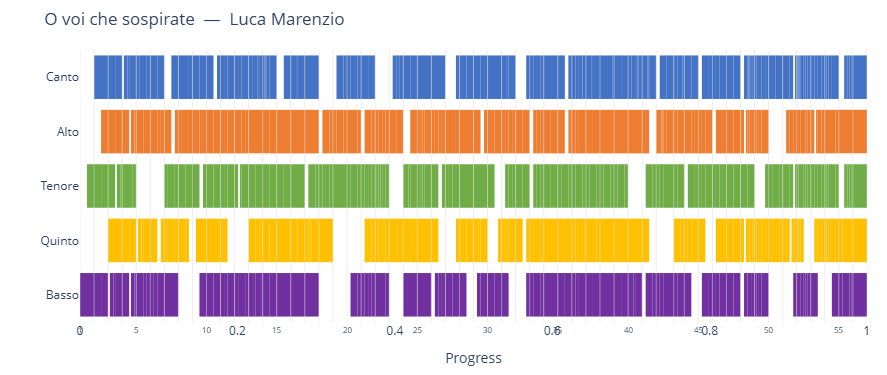

In [22]:
# ── Detect voices dynamically ─────────────────────────────────────────────────
NON_VOICE = {'Measure', 'Beat', 'Composer', 'Title', 'path', 'Progress', 'Sounding'}
voices, voice_note_col, voice_dur_col = [], {}, {}
for i, col in enumerate(output.columns):
    if col in NON_VOICE:
        continue
    if col not in voice_note_col:
        voice_note_col[col] = i; voices.append(col)
    elif col not in voice_dur_col:
        voice_dur_col[col] = i

total_offsets = piece.durations().index.max()
measure_map   = output.groupby('Measure')['Progress'].min()
measure_nums  = measure_map.index.tolist()
measure_progs = measure_map.values.tolist()

# ── Build figure ───────────────────────────────────────────────────────────────
palette = ['#4472C4','#ED7D31','#70AD47','#FFC000','#7030A0',
           '#FF6B6B','#00B0F0','#92D050','#FF00FF','#00B050']
fig = go.Figure()

for i, voice in enumerate(voices):
    n_col = output.iloc[:, voice_note_col[voice]]
    d_col = output.iloc[:, voice_dur_col[voice]]
    mask  = n_col.notna() & (n_col.astype(str) != 'Rest')
    idxs  = np.where(mask.values)[0]
    starts = output['Progress'].values[idxs]
    durs   = d_col.values[idxs].astype(float)
    fig.add_trace(go.Bar(
        name=voice,
        x=(durs / total_offsets).tolist(),
        y=[voice] * len(idxs),
        base=starts.tolist(),
        orientation='h',
        marker=dict(color=palette[i % len(palette)], line=dict(width=0)),
        customdata=np.column_stack([
            output['Measure'].values[idxs].astype(int),
            output['Beat'].values[idxs],
            n_col.values[idxs].astype(str),
            durs,
        ]),
        hovertemplate=(
            f'<b>{voice}</b><br>'
            'M %{customdata[0]}  b %{customdata[1]}<br>'
            'Pitch: %{customdata[2]}  Dur: %{customdata[3]:.0f}<br>'
            '<extra></extra>'
        ),
    ))

fig.update_layout(
    title=f"{output['Title'].iloc[0]}  —  {output['Composer'].iloc[0]}",
    barmode='overlay',
    xaxis=dict(range=[0, 1], title='Progress', showgrid=False),
    yaxis=dict(title=None, categoryorder='array',
               categoryarray=list(reversed(voices))),
    height=150 + len(voices) * 45,
    showlegend=False,
    margin=dict(l=80, r=20, t=50, b=40),
    plot_bgcolor='white',
    shapes=[
        dict(type='line', x0=p, x1=p, y0=0, y1=1,
             xref='x', yref='paper', line=dict(color='#ddd', width=0.5))
        for p in measure_progs
    ],
    annotations=[
        dict(x=p, y=0, xref='x', yref='paper', text=str(int(m)),
             showarrow=False, yanchor='top', xanchor='center', font=dict(size=8))
        for m, p in zip(measure_nums, measure_progs) if m == 1 or m % 5 == 0
    ],
)
fig.show()
download_html(fig, 'voice_activity.html')

### Sonorità complessiva ###
L'asse x rappresenta il 'progresso' (progress) della composizione ossia il suo svolgimento<br>
dal punto 0 (inizio) al punto 1 (fine), con i valori intermedi espressi con numeri decimali.<br>
Le colonne lungo l'asse rappresentano il numero delle voci di volta in volta attive.

In [ ]:
# Sounding count — uses measure_nums / measure_progs from the cell above
df_s = (output[['Progress', 'Measure', 'Beat', 'Sounding']]
        .dropna(subset=['Sounding'])
        .reset_index(drop=True)
        .assign(Measure=lambda x: x['Measure'].astype(int)))

prog   = df_s['Progress'].values
gaps   = np.diff(prog)
widths = np.append(gaps, gaps[-1])   # last bar reuses the previous gap

fig_s = go.Figure(go.Bar(
    x=(prog + widths / 2).tolist(),
    y=df_s['Sounding'].tolist(),
    width=widths.tolist(),
    marker=dict(color='#4472C4', line=dict(width=0)),
    customdata=df_s[['Measure', 'Beat', 'Sounding']].values,
    hovertemplate=(
        'M %{customdata[0]}  b %{customdata[1]}<br>'
        'Sounding: %{customdata[2]:.0f}<br>'
        '<extra></extra>'
    ),
))

fig_s.update_layout(
    title='Sounding voices',
    xaxis=dict(range=[0, 1], title='Progress', showgrid=False),
    yaxis=dict(title='Active voices', dtick=1),
    height=250,
    showlegend=False,
    margin=dict(l=60, r=20, t=50, b=40),
    plot_bgcolor='white',
    bargap=0,
    shapes=[
        dict(type='line', x0=p, x1=p, y0=0, y1=1,
             xref='x', yref='paper', line=dict(color='#ddd', width=0.5))
        for p in measure_progs
    ],
    annotations=[
        dict(x=p, y=0, xref='x', yref='paper', text=str(int(m)),
             showarrow=False, yanchor='top', xanchor='center', font=dict(size=8))
        for m, p in zip(measure_nums, measure_progs) if m == 1 or m % 5 == 0
    ],
)
fig_s.show()
download_html(fig_s, 'sounding_voices.html')